In [21]:
import numpy as np
import numpy.testing as npt
from scipy import stats
from scipy.stats import t,ttest_ind
from scipy.stats import f
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.regression._prediction import get_prediction
from statsmodels.stats.outliers_influence import OLSInfluence,MLEInfluence
from statsmodels.graphics.gofplots import qqplot_2samples,ProbPlot,qqplot
import pandas as pd
from patsy import dmatrices
from numpy.testing import assert_almost_equal, assert_allclose
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
# some_file.py
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\statemodelsStudy')
from olsRegressionAnalysis import dispAnalysisOfVariance, tableDispFormatt,getInvOfProductMat,getRegressionEqn


In [22]:
path  = r"C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\Notes\mlx\stat_analysis\Ch-5-TRANSFORMATIONS_AND_WEIGHTING_TO_CORRECT\DataSet\windMillData.txt"
df = pd.read_csv(path)
print(df.columns)

Index(['Obs', 'WindVelocityXi_mph', 'DCOutputYi'], dtype='object')


In [23]:
X = sm.add_constant(df['WindVelocityXi_mph'])
y = df['DCOutputYi']
need_to_transform = y
res = sm.OLS(y, X).fit()
print(res.params)
print(f"[without transformed ] Mean squared error of the residuals {res.mse_resid}")
resid_without_trasformed = res.resid

const                 0.130875
WindVelocityXi_mph    0.241149
dtype: float64
[without transformed ] Mean squared error of the residuals 0.05572057231729687


In [24]:
# Getting lamdas value using box cox

tableDispFormatt('Get lambda value using boxcox()')
Transformed,lamda = stats.boxcox(need_to_transform)
print(lamda)

=============================== Get lambda value using boxcox() ============================
1.402666453641503


In [25]:
# update y with Box cox transformanations
y = Transformed
res = sm.OLS(y, X).fit()
print(res.params)
print(f"[Box-Cox transformed ] Mean squared error of the residuals {res.mse_resid}")
boxcox_trasformanations = res.resid

const                -0.950154
WindVelocityXi_mph    0.276592
dtype: float64
[Box-Cox transformed ] Mean squared error of the residuals 0.043833510983165125


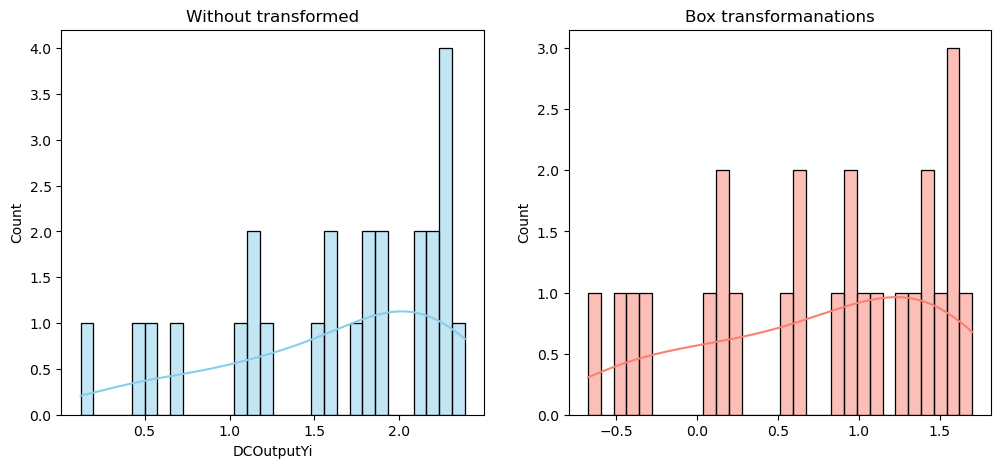

In [26]:
# Compare distributions
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['DCOutputYi'], bins=30,kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Without transformed')

sns.histplot(x=Transformed, bins=30,kde=True, ax=ax[1], color='salmon')
ax[1].set_title('Box transformanations')


plt.show()

we can see here their is not any effect MSres after transformanations
MSres before transformanations = 0.05572057231729687
And after transformanations = 0.043833510983165125